# Heart Disease Prediction using Machine Learning

## Predictive Analytics Project

This project aims to predict the presence of heart disease using clinical and demographic data. The goal is to support healthcare providers in identifying high-risk patients and improving early diagnosis.

**Models Used:**
- Logistic Regression
- Decision Tree
- Random Forest

**Tools:**
- Python
- Pandas, NumPy
- Scikit-learn
- Matplotlib, Seaborn

## Dataset Overview

The dataset contains 920 patient records with various clinical and demographic features, including age, sex, chest pain type, blood pressure, cholesterol levels, and heart rate.

The target variable indicates whether a patient has heart disease:
- 0 = No Disease
- 1 = Disease

This dataset is suitable for a classification problem.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_uci.csv.xlsx to heart_disease_uci.csv.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel("heart_disease_uci.csv.xlsx")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,1.0,lv hypertrophy,150.0,0.0,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,0.0,lv hypertrophy,108.0,1.0,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,0.0,lv hypertrophy,129.0,1.0,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,0.0,normal,187.0,0.0,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,0.0,lv hypertrophy,172.0,0.0,1.4,upsloping,0.0,normal,0


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("heart_disease_uci.csv.xlsx")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape (rows, columns):")
print(df.shape)

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Values per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

categorical_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "thal"]

for col in categorical_cols:
    if col in df.columns:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())

print("\nTarget column (num) distribution:")
if "num" in df.columns:
    print(df["num"].value_counts())

print("\nDuplicate rows:")
print(df.duplicated().sum())

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol  fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0  1.0   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  0.0   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  0.0   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  0.0   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  0.0   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0    0.0      2.3  downsloping  0.0   
1  lv hypertrophy   108.0    1.0      1.5         flat  3.0   
2  lv hypertrophy   129.0    1.0      2.6         flat  2.0   
3          normal   187.0    0.0      3.5  downsloping  0.0   
4  lv hypertrophy   172.0    0.0      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  

Datas

## Data Cleaning

The dataset contained missing values and variables with excessive missing data.

- Columns with significant missing values (ca, thal, slope) were removed
- Numerical features were filled using median values
- Categorical features were filled using mode
- The target variable was converted into a binary classification format

These steps ensured data quality and prepared the dataset for modeling.

In [ ]:
import pandas as pd

df = pd.read_excel("heart_disease_uci.csv.xlsx")

df = df.drop(columns=["id", "ca", "thal", "slope"])

df["target"] = df["num"].apply(lambda x: 0 if x == 0 else 1)
df = df.drop(columns=["num"])

num_cols = df.select_dtypes(include=["float64", "int64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

print("\nDataset shape after cleaning:")
print(df.shape)

print("\nTarget distribution:")
print(df["target"].value_counts())

Missing values after cleaning:
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
target      0
dtype: int64

Dataset shape after cleaning:
(920, 12)

Target distribution:
target
1    509
0    411
Name: count, dtype: int64


This project aims to predict whether a patient has heart disease based on clinical health indicators. The goal is to help healthcare providers identify high-risk patients earlier and support preventive care decisions.


## Exploratory Data Analysis (EDA)

Exploratory analysis was conducted to identify patterns and relationships between variables and heart disease.

Key goals:
- Understand distribution of variables
- Identify important predictors
- Detect anomalies and trends

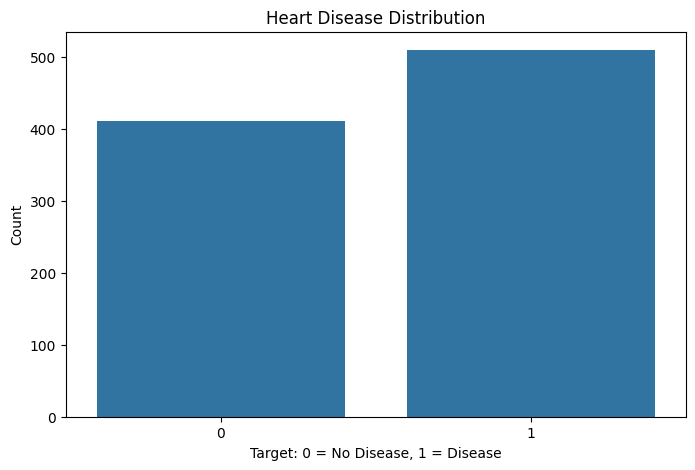

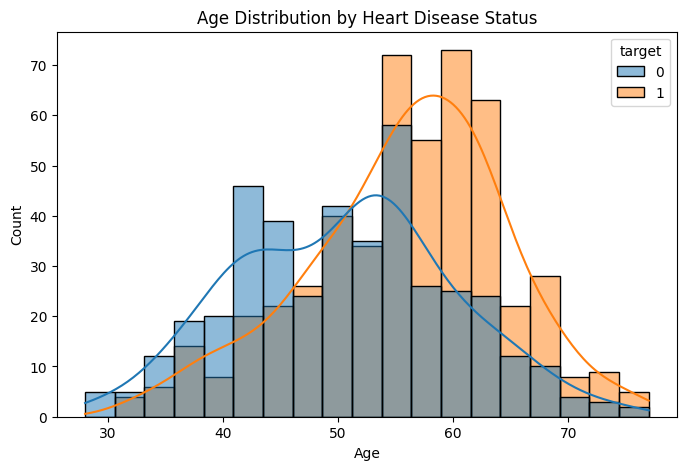

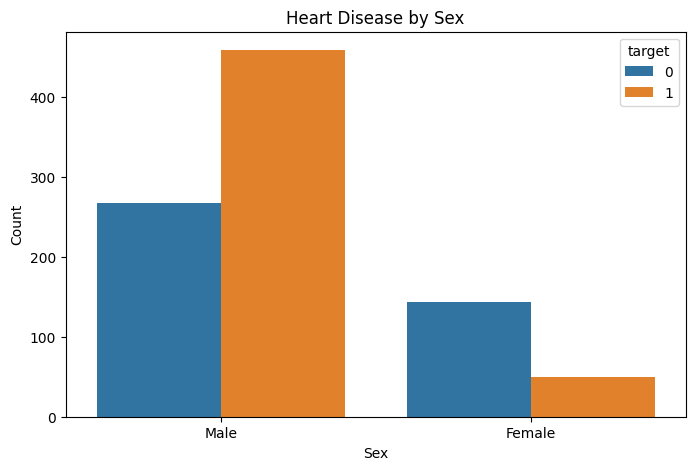

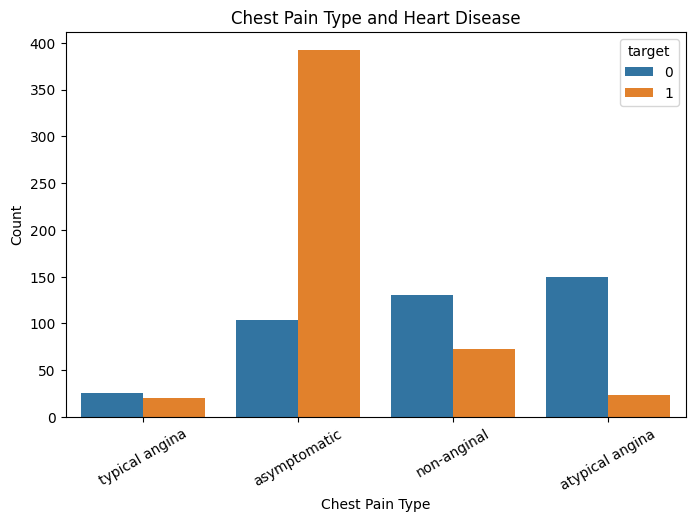

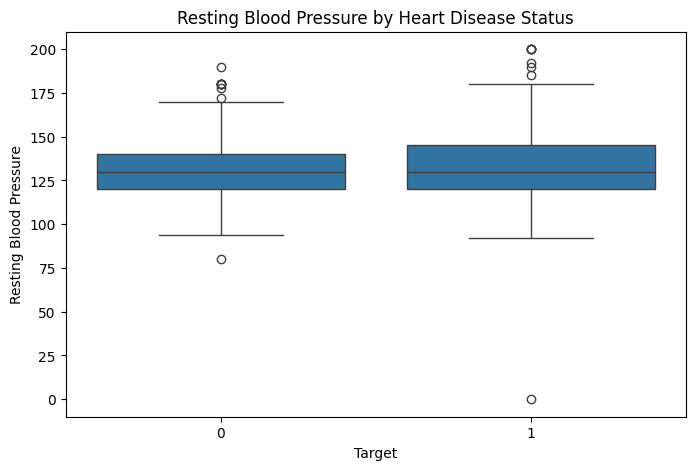

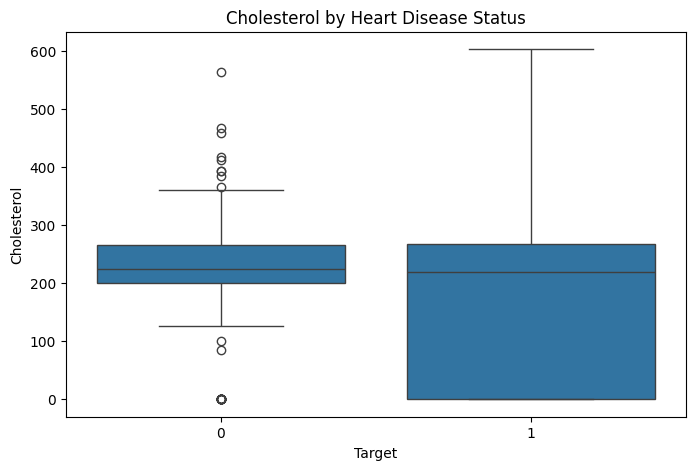

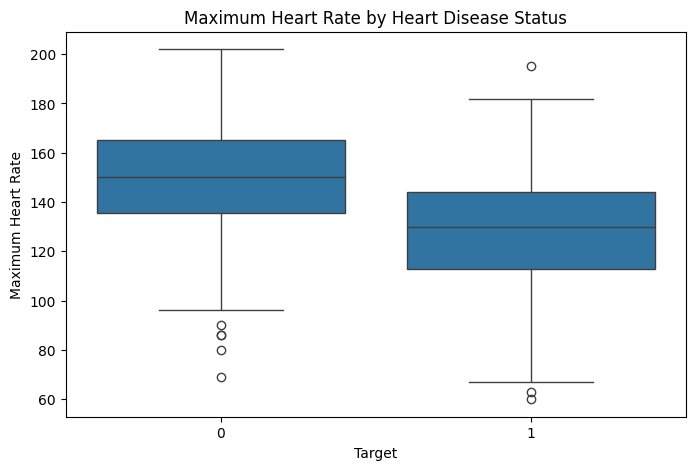

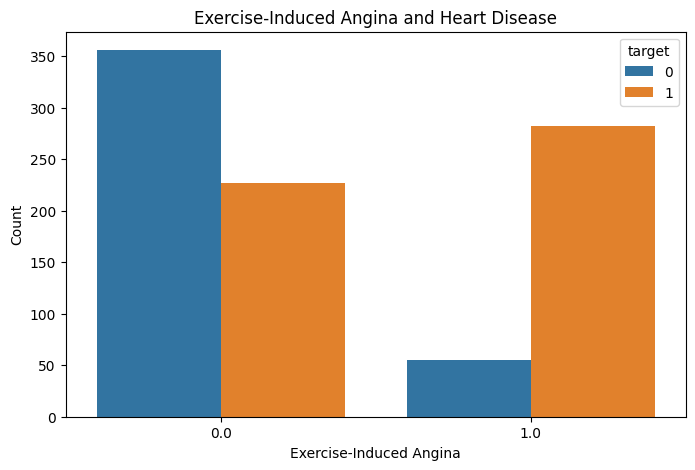

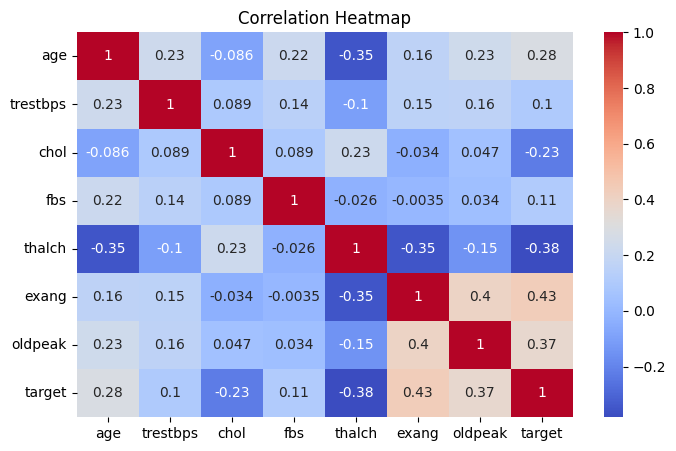

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)

# 1. Target distribution
sns.countplot(data=df, x="target")
plt.title("Heart Disease Distribution")
plt.xlabel("Target: 0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.show()

# 2. Age distribution by target
sns.histplot(data=df, x="age", hue="target", kde=True)
plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# 3. Sex vs heart disease
sns.countplot(data=df, x="sex", hue="target")
plt.title("Heart Disease by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

# 4. Chest pain type vs heart disease
sns.countplot(data=df, x="cp", hue="target")
plt.title("Chest Pain Type and Heart Disease")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()

# 5. Resting blood pressure by target
sns.boxplot(data=df, x="target", y="trestbps")
plt.title("Resting Blood Pressure by Heart Disease Status")
plt.xlabel("Target")
plt.ylabel("Resting Blood Pressure")
plt.show()

# 6. Cholesterol by target
sns.boxplot(data=df, x="target", y="chol")
plt.title("Cholesterol by Heart Disease Status")
plt.xlabel("Target")
plt.ylabel("Cholesterol")
plt.show()

# 7. Maximum heart rate by target
sns.boxplot(data=df, x="target", y="thalch")
plt.title("Maximum Heart Rate by Heart Disease Status")
plt.xlabel("Target")
plt.ylabel("Maximum Heart Rate")
plt.show()

# 8. Exercise-induced angina vs target
sns.countplot(data=df, x="exang", hue="target")
plt.title("Exercise-Induced Angina and Heart Disease")
plt.xlabel("Exercise-Induced Angina")
plt.ylabel("Count")
plt.show()

# 9. Correlation heatmap for numerical variables
numeric_df = df.select_dtypes(include=["float64", "int64"])

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Methodology

This project follows a structured machine learning workflow:

### Data Cleaning
- Removed columns with excessive missing values (ca, thal, slope)
- Filled numerical missing values using median
- Filled categorical missing values using mode
- Converted target variable into binary classification

### Data Preparation
- Applied one-hot encoding to categorical variables
- Split data into training and testing sets (80/20)
- Applied feature scaling for Logistic Regression

### Model Selection
Three models were used:
- Logistic Regression (baseline)
- Decision Tree (non-linear patterns)
- Random Forest (ensemble model)

### Evaluation Metrics
Models were evaluated using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

## Modeling

Three machine learning models were implemented:

1. Logistic Regression (baseline model)
2. Decision Tree (captures non-linear patterns)
3. Random Forest (ensemble model for improved accuracy)

The dataset was split into training and testing sets using an 80/20 ratio. Feature scaling was applied to Logistic Regression.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# 1. Prepare features and target
X = df.drop("target", axis=1)
y = df["target"]

# 2. Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Scale data (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MODEL 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))

# MODEL 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("\n Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))

# MODEL 3: Random Forest (BEST)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("\n Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))

Logistic Regression
Accuracy: 0.8043478260869565
              precision    recall  f1-score   support

           0       0.74      0.80      0.77        75
           1       0.85      0.81      0.83       109

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.81       184

[[60 15]
 [21 88]]

 Decision Tree
Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.66      0.79      0.72        75
           1       0.83      0.72      0.77       109

    accuracy                           0.75       184
   macro avg       0.75      0.76      0.75       184
weighted avg       0.76      0.75      0.75       184

[[59 16]
 [30 79]]

 Random Forest
Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.77      0.83      0.79        75
           1       0.87      0.83      0.85       109

    accuracy       

## Results & Model Evaluation

Three models were evaluated: Logistic Regression, Decision Tree, and Random Forest.

- Logistic Regression achieved ~80% accuracy with balanced performance.
- Decision Tree achieved ~75% accuracy but showed weaker recall.
- Random Forest achieved the best performance (~83% accuracy) and the most balanced results.

The Random Forest model produced fewer false negatives, making it the most reliable model for predicting heart disease.

In [8]:
import pandas as pd

# Store results
results = {
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
}

results_df = pd.DataFrame(results)

# Display table
results_df

,Model,Accuracy
0,Logistic Regression,0.804348
1,Decision Tree,0.750000
2,Random Forest,0.826087


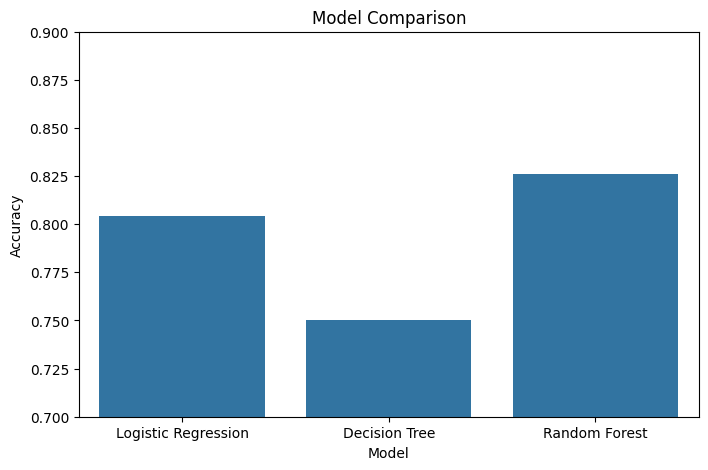

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Comparison")
plt.ylim(0.7, 0.9)
plt.show()

## Model Comparison

The comparison of model performance shows that the Random Forest model achieved the highest accuracy, followed by Logistic Regression and Decision Tree.

While Logistic Regression provided stable and interpretable results, the Decision Tree model showed weaker performance, likely due to overfitting or limited generalization.

The Random Forest model outperformed the others by combining multiple decision trees, resulting in improved accuracy and robustness.

## Business Insights

The analysis identified several key factors associated with heart disease risk:

- Older patients are more likely to develop heart disease
- Lower maximum heart rate is linked to higher risk
- Exercise-induced angina is a strong predictor
- Asymptomatic chest pain patients may still be high-risk

These findings suggest that healthcare providers should prioritize screening for high-risk individuals. The Random Forest model can be used as a decision-support tool to improve early diagnosis and reduce the risk of missed cases.

## Conclusion

This project successfully developed a machine learning model to predict heart disease.

Among the models tested, Random Forest performed the best and demonstrated strong predictive capability.

Machine learning can play an important role in assisting healthcare providers with early detection and better decision-making.